# 06 — Model Explainability with SHAP

## Why this notebook matters

Notebooks 03–05 produce *predictions*. This one produces **reasons**.

For a groundwater safety system that is not optional. If the model labels a village's water
**High risk**, the responsible answer to *"why?"* cannot be *"the model said so."* An official
deciding where to send testing kits needs to know **which measurements drove the call**.

SHAP (SHapley Additive exPlanations) assigns each feature a signed contribution to each individual
prediction, with a useful guarantee: the contributions **sum to the prediction**. So explanations
are additive and auditable, not hand-wavy.

Both final classifiers are **XGBoost**, so we use `TreeExplainer` — exact for tree ensembles, not a
sampling approximation.

## Two levels of explanation

| Level | Question answered | Audience |
|---|---|---|
| **Global** | Which features drive the model *overall*? | Model validation, report |
| **Local** | Why did *this specific well* get *this* label? | Field officer, API response |

We produce both, for both classifiers.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
plt.style.use("ggplot")
pd.set_option("display.max_columns", None)
os.makedirs("../docs/screenshots", exist_ok=True)

print(f"SHAP version: {shap.__version__}")

SHAP version: 0.52.0


---
# Part 1 — Drinking Water Classifier

## 1.1 Rebuild the exact feature matrix

We must reproduce the *same* preprocessing the model was trained on, or the SHAP values are
meaningless. We rebuild from the saved `feature_names.pkl` rather than re-deriving by hand.

In [2]:
drink_model  = joblib.load("../models/drinking/drinking_model.pkl")
drink_feats  = joblib.load("../models/drinking/feature_names.pkl")
drink_le     = joblib.load("../models/drinking/label_encoder.pkl")
drink_classes = list(drink_le["classes_"])   # ['Safe','Moderate','High'] (ordinal 0,1,2)

df = pd.read_csv("../data/processed/groundwater_ml_ready.csv")

# Same leakage-controlled feature set as notebook 04
risk_to_code = {n: i for i, n in enumerate(drink_classes)}
y_drink = df["drinking_risk"].map(risk_to_code)

X_drink = pd.get_dummies(df, columns=["district"], prefix="dist")
X_drink = X_drink.reindex(columns=drink_feats, fill_value=0)  # exact train-time columns/order

assert list(X_drink.columns) == list(drink_feats), "Feature mismatch vs training!"

# Explain the held-out test split (the honest view of the deployed model)
_, X_te_d, _, y_te_d = train_test_split(
    X_drink, y_drink, test_size=0.2, stratify=y_drink, random_state=RANDOM_STATE
)

print(f"Model    : {type(drink_model).__name__}")
print(f"Classes  : {drink_classes}")
print(f"Features : {X_te_d.shape[1]}")
print(f"Explaining {X_te_d.shape[0]} held-out test wells")

Model    : XGBClassifier
Classes  : ['Safe', 'Moderate', 'High']
Features : 38
Explaining 222 held-out test wells


## 1.2 Compute SHAP values

In [4]:
explainer_d = shap.TreeExplainer(drink_model)
sv_d = explainer_d.shap_values(X_te_d)

# Multiclass -> list of arrays (or 3D array), one per class
sv_d = np.array(sv_d)
print(f"SHAP array shape: {sv_d.shape}")
print("(samples, features, classes) or (classes, samples, features) depending on version")

# Normalise to shape (n_classes, n_samples, n_features)
if sv_d.ndim == 3 and sv_d.shape[-1] == len(drink_classes):
    sv_d = np.transpose(sv_d, (2, 0, 1))
print(f"Normalised to: {sv_d.shape}  -> ({len(drink_classes)} classes, samples, features)")

SHAP array shape: (222, 38, 3)
(samples, features, classes) or (classes, samples, features) depending on version
Normalised to: (3, 222, 38)  -> (3 classes, samples, features)


## 1.3 Global explanation — what drives risk overall?

Mean |SHAP| across all test wells. Unlike XGBoost's built-in `feature_importances_` (which is
split-count based and can be biased toward high-cardinality features), SHAP importance is
**consistent** and directly tied to prediction impact.

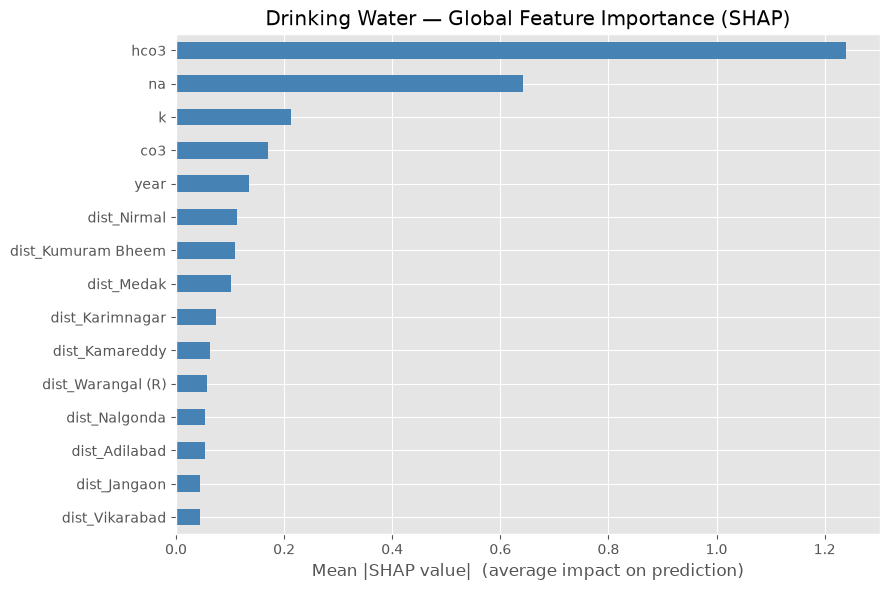

Top 15 drivers:
hco3                  1.2404
na                    0.6421
k                     0.2125
co3                   0.1700
year                  0.1349
dist_Nirmal           0.1122
dist_Kumuram Bheem    0.1090
dist_Medak            0.1013
dist_Karimnagar       0.0746
dist_Kamareddy        0.0630
dist_Warangal (R)     0.0578
dist_Nalgonda         0.0545
dist_Adilabad         0.0545
dist_Jangaon          0.0449
dist_Vikarabad        0.0446


In [5]:
# Aggregate importance across all classes
global_imp = pd.Series(
    np.abs(sv_d).mean(axis=(0, 1)),   # mean |SHAP| over classes and samples
    index=X_te_d.columns
).sort_values(ascending=False)

top15 = global_imp.head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15[::-1].plot.barh(ax=ax, color="steelblue")
ax.set_xlabel("Mean |SHAP value|  (average impact on prediction)")
ax.set_title("Drinking Water — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../docs/screenshots/shap_global_drinking.png", dpi=300, bbox_inches="tight")
plt.show()

print("Top 15 drivers:")
print(top15.round(4).to_string())

### Beeswarm — importance *and* direction

The bar chart shows *how much* a feature matters. The beeswarm also shows **which way** it pushes:
each dot is a well, colour is the feature's value, position is its SHAP contribution.

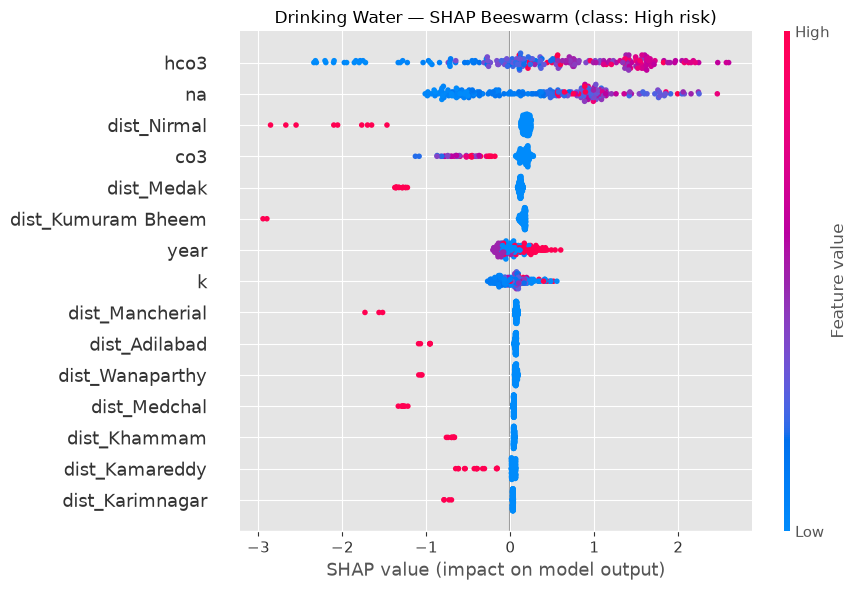

Read: dots right of centre push TOWARD 'High risk'; left pushes away.
Colour = the feature's own value (red = high, blue = low).


In [6]:
# Beeswarm for the 'High' risk class — the class we most care about explaining
high_idx = drink_classes.index("High")

shap.summary_plot(
    sv_d[high_idx], X_te_d,
    max_display=15, show=False, plot_size=(9, 6)
)
plt.title("Drinking Water — SHAP Beeswarm (class: High risk)", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/screenshots/shap_beeswarm_drinking.png", dpi=300, bbox_inches="tight")
plt.show()

print("Read: dots right of centre push TOWARD 'High risk'; left pushes away.")
print("Colour = the feature's own value (red = high, blue = low).")

## 1.4 Local explanation — why *this* well?

This is what the Flask API returns alongside a prediction. We take the well the model is *most
confident* is High risk and decompose that decision.

In [7]:
proba = drink_model.predict_proba(X_te_d)
i = int(np.argmax(proba[:, high_idx]))   # most confidently 'High' well

true_lbl = drink_classes[int(y_te_d.iloc[i])]
pred_lbl = drink_classes[int(proba[i].argmax())]

print(f"Well index   : {X_te_d.index[i]}")
print(f"True label   : {true_lbl}")
print(f"Predicted    : {pred_lbl}  (confidence {proba[i].max():.1%})")
print()

contrib = pd.Series(sv_d[high_idx][i], index=X_te_d.columns)
contrib = contrib[contrib.abs() > 1e-6].sort_values(key=abs, ascending=False).head(10)

print("Top contributions toward 'High risk':")
for feat, val in contrib.items():
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat:22s} {val:+.3f}  ({direction} High-risk score)")

Well index   : 372
True label   : High
Predicted    : High  (confidence 99.9%)

Top contributions toward 'High risk':
  hco3                   +1.552  (increases High-risk score)
  na                     +0.997  (increases High-risk score)
  dist_Nirmal            +0.241  (increases High-risk score)
  co3                    +0.222  (increases High-risk score)
  dist_Kumuram Bheem     +0.178  (increases High-risk score)
  k                      +0.178  (increases High-risk score)
  year                   +0.129  (increases High-risk score)
  dist_Medak             +0.119  (increases High-risk score)
  dist_Mancherial        +0.068  (increases High-risk score)
  dist_Kamareddy         +0.062  (increases High-risk score)


### Waterfall — the additive decomposition

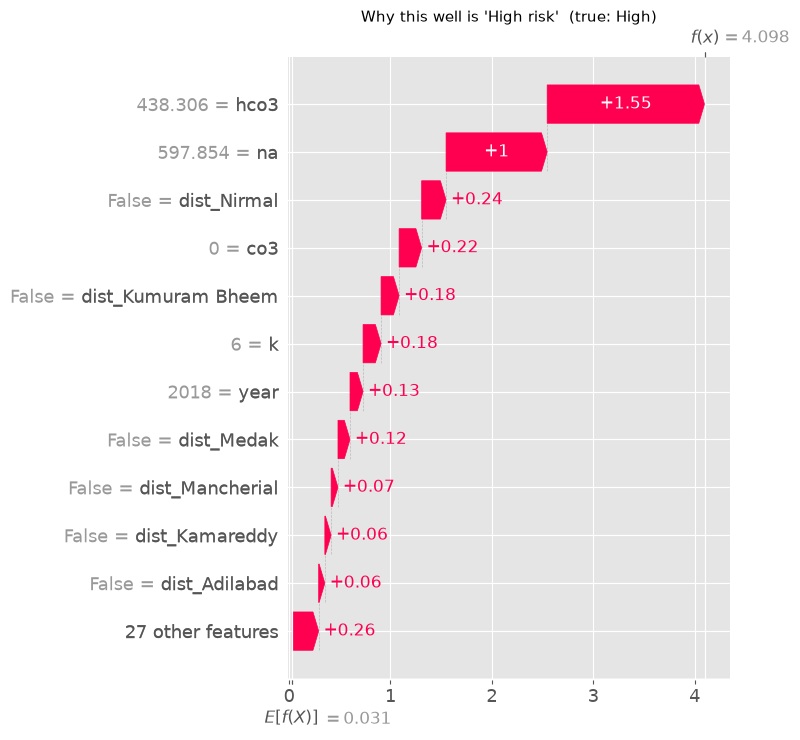

The bars sum from the base value (average prediction) to this well's actual score.


In [8]:
expl = shap.Explanation(
    values        = sv_d[high_idx][i],
    base_values   = float(np.array(explainer_d.expected_value).ravel()[high_idx]),
    data          = X_te_d.iloc[i].values,
    feature_names = list(X_te_d.columns)
)

shap.plots.waterfall(expl, max_display=12, show=False)
plt.title(f"Why this well is 'High risk'  (true: {true_lbl})", fontsize=11)
plt.tight_layout()
plt.savefig("../docs/screenshots/shap_waterfall_drinking.png", dpi=300, bbox_inches="tight")
plt.show()

print("The bars sum from the base value (average prediction) to this well's actual score.")

---
# Part 2 — Irrigation Classifier

## 2.1 Load and rebuild

**Artifact note:** `models/irrigation/label_encoder.pkl` stores *encoded integers*, not the original
`C2S1`-style names (it was fitted before the tiny-class merge). We therefore reconstruct the class
names here rather than trusting that artifact — otherwise every SHAP plot would be labelled with
meaningless numbers.

In [9]:
irr_model = joblib.load("../models/irrigation/irrigation_model.pkl")
irr_feats = joblib.load("../models/irrigation/feature_names.pkl")

df_irr = pd.read_csv("../data/processed/groundwater_clean_2018_2020.csv")

# Same preparation as notebook 03: valid compound labels only
valid = df_irr["irrigation_class"].str.match(r"^C[1-4]S[1-4]$", na=False)
df_irr = df_irr[valid].reset_index(drop=True)

X_irr = df_irr[irr_feats].copy()
X_irr = X_irr.fillna(X_irr.median(numeric_only=True))

# Reconstruct readable class names in the model's own label order
from sklearn.preprocessing import LabelEncoder
le_tmp = LabelEncoder().fit(df_irr["irrigation_class"])
y_irr_full = le_tmp.transform(df_irr["irrigation_class"])

# Merge tiny classes exactly as notebook 03 did (<6 samples -> nearest code)
counts = pd.Series(y_irr_full).value_counts()
tiny = counts[counts < 6].index.tolist()
big  = counts[counts >= 6].index.tolist()
merge_map = {t: min(big, key=lambda b: abs(b - t)) for t in tiny}
y_irr = pd.Series(y_irr_full).replace(merge_map)

kept_codes  = sorted(y_irr.unique())
irr_classes = [le_tmp.classes_[c] for c in kept_codes]
code_to_pos = {c: i for i, c in enumerate(kept_codes)}
y_irr = y_irr.map(code_to_pos)

_, X_te_i, _, y_te_i = train_test_split(
    X_irr, y_irr, test_size=0.2, stratify=y_irr, random_state=RANDOM_STATE
)

print(f"Model    : {type(irr_model).__name__}")
print(f"Classes  : {irr_classes}")
print(f"Features : {list(X_te_i.columns)}")
print(f"Explaining {X_te_i.shape[0]} held-out test wells")

Model    : RandomForestClassifier
Classes  : ['C2S1', 'C3S1', 'C3S2', 'C3S3', 'C4S1', 'C4S2', 'C4S4']
Features : ['ph', 'co3', 'hco3', 'cl', 'f', 'no3', 'so4', 'na', 'k', 'ca', 'mg', 'th']
Explaining 221 held-out test wells


## 2.2 Global explanation

SHAP shape: (7, 221, 12)


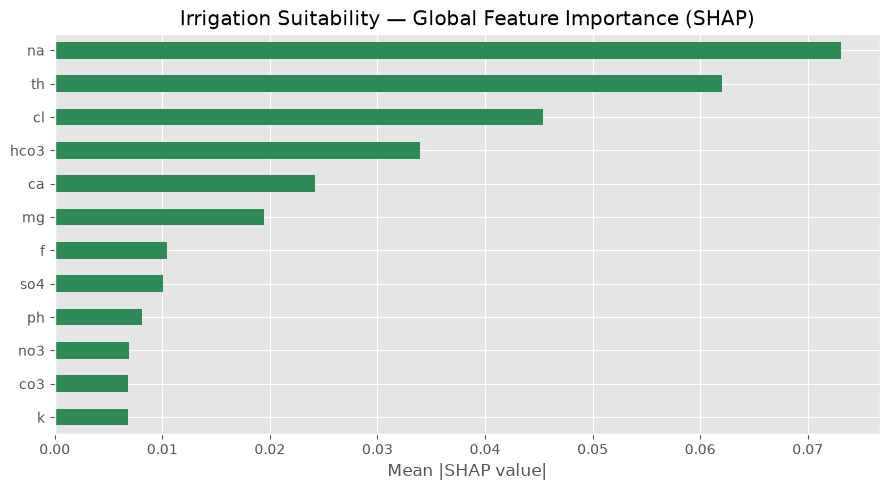

na      0.0731
th      0.0620
cl      0.0454
hco3    0.0339
ca      0.0242
mg      0.0194
f       0.0104
so4     0.0101
ph      0.0081
no3     0.0069
co3     0.0068
k       0.0068


In [10]:
explainer_i = shap.TreeExplainer(irr_model)
sv_i = np.array(explainer_i.shap_values(X_te_i))

if sv_i.ndim == 3 and sv_i.shape[-1] == len(irr_classes):
    sv_i = np.transpose(sv_i, (2, 0, 1))
print(f"SHAP shape: {sv_i.shape}")

global_imp_i = pd.Series(
    np.abs(sv_i).mean(axis=(0, 1)), index=X_te_i.columns
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
global_imp_i[::-1].plot.barh(ax=ax, color="seagreen")
ax.set_xlabel("Mean |SHAP value|")
ax.set_title("Irrigation Suitability — Global Feature Importance (SHAP)")
plt.tight_layout()
plt.savefig("../docs/screenshots/shap_global_irrigation.png", dpi=300, bbox_inches="tight")
plt.show()

print(global_imp_i.round(4).to_string())

### Beeswarm — dominant irrigation class

Explains the majority class, where the model has the most evidence.

Explaining class: C3S1


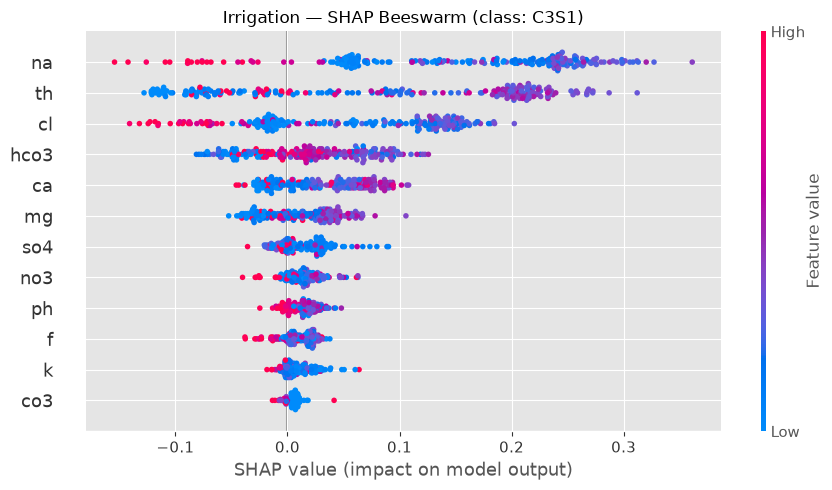

In [11]:
maj = int(pd.Series(y_te_i).value_counts().idxmax())
print(f"Explaining class: {irr_classes[maj]}")

shap.summary_plot(sv_i[maj], X_te_i, max_display=12, show=False, plot_size=(9, 5))
plt.title(f"Irrigation — SHAP Beeswarm (class: {irr_classes[maj]})", fontsize=12)
plt.tight_layout()
plt.savefig("../docs/screenshots/shap_beeswarm_irrigation.png", dpi=300, bbox_inches="tight")
plt.show()

## 2.3 Local explanation

In [12]:
proba_i = irr_model.predict_proba(X_te_i)
j = int(np.argmax(proba_i[:, maj]))

print(f"Well index : {X_te_i.index[j]}")
print(f"True       : {irr_classes[int(y_te_i.iloc[j])]}")
print(f"Predicted  : {irr_classes[int(proba_i[j].argmax())]}  (confidence {proba_i[j].max():.1%})")
print()

contrib_i = pd.Series(sv_i[maj][j], index=X_te_i.columns)
contrib_i = contrib_i.sort_values(key=abs, ascending=False)
print(f"Contributions toward '{irr_classes[maj]}':")
for feat, val in contrib_i.head(10).items():
    print(f"  {feat:8s} (value={X_te_i.iloc[j][feat]:8.2f})  SHAP {val:+.3f}")

Well index : 402
True       : C3S1
Predicted  : C3S1  (confidence 100.0%)

Contributions toward 'C3S1':
  na       (value=   79.00)  SHAP +0.237
  th       (value=  439.93)  SHAP +0.226
  cl       (value=  120.00)  SHAP +0.128
  ca       (value=  112.00)  SHAP +0.084
  ph       (value=    7.80)  SHAP +0.031
  so4      (value=   21.00)  SHAP +0.031
  mg       (value=   38.90)  SHAP +0.030
  hco3     (value=  370.00)  SHAP +0.028
  k        (value=    0.96)  SHAP +0.024
  f        (value=    0.77)  SHAP +0.020


---
## 3. Cross-model comparison — do the two models agree on what matters?

In [13]:
comp = pd.DataFrame({
    "Drinking (SHAP)"  : global_imp.reindex(["na", "k", "co3", "hco3"]),
    "Irrigation (SHAP)": global_imp_i.reindex(["na", "k", "co3", "hco3"]),
}).round(4)

print("Shared non-BIS chemistry features — importance in each model:")
print(comp.to_string())
print()
print("The drinking model may only use contextual/non-BIS chemistry (leakage control),")
print("while the irrigation model sees the wider ion panel — so the two rank features")
print("differently by design, not by disagreement.")

Shared non-BIS chemistry features — importance in each model:
      Drinking (SHAP)  Irrigation (SHAP)
na             0.6421             0.0731
k              0.2125             0.0068
co3            0.1700             0.0068
hco3           1.2404             0.0339

The drinking model may only use contextual/non-BIS chemistry (leakage control),
while the irrigation model sees the wider ion panel — so the two rank features
differently by design, not by disagreement.


## 4. Summary — what SHAP bought us

**Global.** We can now state *which measurements drive each model*, using a consistent importance
measure rather than XGBoost's split-count heuristic (which is biased toward high-cardinality
features like the 33 one-hot districts).

**Local.** Every prediction can be decomposed into signed, additive feature contributions. This is
the payload the Flask API should return next to each label — it converts *"High risk"* into
*"High risk **because** nitrate and sodium are elevated"*, which is the difference between an
alert an official can act on and one they must take on faith.

**Honest caveat.** SHAP explains *what the model learned*, not *ground truth*. If a feature is
merely correlated with contamination rather than causing it, SHAP will faithfully report the
model's reliance on that correlation. These are explanations of the model, not of hydrogeology.

**Saved figures** (`docs/screenshots/`):
`shap_global_drinking.png`, `shap_beeswarm_drinking.png`, `shap_waterfall_drinking.png`,
`shap_global_irrigation.png`, `shap_beeswarm_irrigation.png`

**Next:** the ML work is complete. The project now moves to the **Flask API** (serving all three
models + SHAP explanations) and the **React frontend**.